In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/snehachalla73/best-final-model/effb0_fast_best.pth
/kaggle/input/competitions/aptos2019-blindness-detection/sample_submission.csv
/kaggle/input/competitions/aptos2019-blindness-detection/train.csv
/kaggle/input/competitions/aptos2019-blindness-detection/test.csv
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/ef476be214d4.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/6dcde47060f9.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/ec363f48867b.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/17f6c7072f61.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/b49b2fac2514.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/af6166d57f13.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/8d13c46e7d75.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/c3b15bf9b4bc.png
/kaggle/input/comp

In [2]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from torch.optim.lr_scheduler import OneCycleLR

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    cohen_kappa_score
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

print("All libraries imported!")

All libraries imported!


In [3]:
# Cell 2: Optimized Configuration (Fast Training)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Optimized for speed
IMG_SIZE = 224  # Standard size (faster than 260)
BATCH_SIZE = 64  # Larger batch = faster training
EPOCHS = 30  # Reduced from 60
BACKBONE_LR = 2e-4  # Slightly higher
HEAD_LR = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 8  # Early stopping
MIXUP_PROB = 0.2  # Reduced
LABEL_SMOOTHING = 0.1

BASE = '/kaggle/input/competitions/aptos2019-blindness-detection'
CLASS_NAMES = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
NUM_CLASSES = 5
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

print("Optimized configuration loaded!")
print(f"Epochs: {EPOCHS}, Batch Size: {BATCH_SIZE}, Image Size: {IMG_SIZE}")

Device: cpu
Optimized configuration loaded!
Epochs: 30, Batch Size: 64, Image Size: 224


In [4]:
# Cell 4: EfficientNet-B0 (Optimized)

class EfficientNetB0_DR(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.4):
        super().__init__()
        base = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )
        self.features = base.features
        self.avgpool = base.avgpool
        
        # Simpler classifier (faster)
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(1280, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.flatten(1)
        return self.classifier(x)
    
    def extract_features(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.flatten(1)
        return x

print("EfficientNet-B0 defined!")

EfficientNet-B0 defined!


In [5]:
model = EfficientNetB0_DR().to(DEVICE)

print("Model created!")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 116MB/s] 


Model created!


In [6]:
model.load_state_dict(
    torch.load(
        "/kaggle/input/datasets/snehachalla73/best-final-model/effb0_fast_best.pth",
        map_location=DEVICE
    )
)

model.eval()

print("Weights loaded!")

Weights loaded!


In [7]:
def apply_clahe_fast(image_path, img_size=IMG_SIZE, clip_limit=2.0):
    """Fast CLAHE - no sharpening overhead"""
    try:
        img = cv2.imread(image_path)
        if img is None:
            raise ValueError('Cannot read')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(8, 8))
        l_c = clahe.apply(l)
        result = cv2.cvtColor(cv2.merge([l_c, a, b]), cv2.COLOR_LAB2RGB)
        
        return Image.fromarray(result)
    except Exception:
        return Image.open(image_path).convert('RGB').resize((img_size, img_size))

def find_image(id_code, folders):
    for folder in folders:
        for ext in ['.png', '.jpeg', '.jpg']:
            p = os.path.join(BASE, folder, str(id_code) + ext)
            if os.path.exists(p):
                return p
    return None

class FundusDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = apply_clahe_fast(row['filepath'], IMG_SIZE)
        if self.transform:
            img = self.transform(img)
        return img, int(row['label'])

def mixup_batch(imgs, labels, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    bs = imgs.size(0)
    idx = torch.randperm(bs, device=imgs.device)
    mixed = lam * imgs + (1 - lam) * imgs[idx]
    return mixed, labels, labels[idx], lam

print("Fast helper functions ready!")

Fast helper functions ready!


In [8]:
train_tfm = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.3),
    T.RandomRotation(30),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.02),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

val_tfm = T.Compose([
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

print("Efficient transforms defined!")

Efficient transforms defined!


In [9]:


TRAIN_FOLDER = ['train_images']
df_raw = pd.read_csv(f'{BASE}/train.csv')
df_raw['label'] = df_raw['diagnosis']
df_raw['filepath'] = df_raw['id_code'].apply(
    lambda x: find_image(x, TRAIN_FOLDER))
df_raw = df_raw[df_raw['filepath'].notna()].reset_index(drop=True)

df_tr, df_te = train_test_split(
    df_raw, test_size=0.20, stratify=df_raw['label'], random_state=SEED)

print(f'Train: {len(df_tr)} | Test: {len(df_te)}')
print('\nClass distribution (train):')
for i, name in enumerate(CLASS_NAMES):
    c = (df_tr['label'] == i).sum()
    print(f'  {name:15s}: {c:4d}')

train_dl = DataLoader(FundusDataset(df_tr, train_tfm),
                      batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_dl = DataLoader(FundusDataset(df_te, val_tfm),
                     batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

cw = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=df_tr['label'].values)
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(cw, dtype=torch.float).to(DEVICE),
    label_smoothing=LABEL_SMOOTHING
)

print('\nClass weights:', {n: f'{w:.3f}' for n, w in zip(CLASS_NAMES, cw)})
print('✅ Data ready!')

Train: 2929 | Test: 733

Class distribution (train):
  No DR          : 1444
  Mild           :  296
  Moderate       :  799
  Severe         :  154
  Proliferative  :  236

Class weights: {'No DR': '0.406', 'Mild': '1.979', 'Moderate': '0.733', 'Severe': '3.804', 'Proliferative': '2.482'}
✅ Data ready!


In [10]:
@torch.no_grad()
def extract_features(model, dataloader, device):
    all_features = []
    all_labels = []

    for images, labels in tqdm(dataloader):
        images = images.to(device)

        features = model.extract_features(images).cpu().numpy()

        all_features.append(features)
        all_labels.append(labels.numpy())

    return np.vstack(all_features), np.concatenate(all_labels)

In [11]:
print("\nExtracting training features...")
train_features, train_labels = extract_features(
    model, train_dl, DEVICE
)

print("Extracting test features...")
test_features, test_labels = extract_features(
    model, test_dl, DEVICE
)

print(f"\nDone! Train: {train_features.shape}, Test: {test_features.shape}")


Extracting training features...


100%|██████████| 46/46 [04:08<00:00,  5.40s/it]


Extracting test features...


100%|██████████| 12/12 [01:34<00:00,  7.88s/it]


Done! Train: (2929, 1280), Test: (733, 1280)


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

print("\nTraining SVM...")

scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_features)
test_scaled = scaler.transform(test_features)

param_grid = {
    'C': [1, 5, 10, 50],
    'gamma': ['scale', 0.01],
    'kernel': ['rbf'],
    'class_weight': ['balanced']
}

grid_search = GridSearchCV(
    SVC(random_state=SEED, probability=True),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(train_scaled, train_labels)

print(f"\nBest parameters: {grid_search.best_params_}")

best_svm = SVC(
    kernel='rbf',
    C=grid_search.best_params_['C'],
    gamma=grid_search.best_params_['gamma'],
    class_weight='balanced',
    random_state=SEED,
    probability=True
)

best_svm.fit(train_scaled, train_labels)


Training SVM...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best parameters: {'C': 10, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}


SVC(C=10, class_weight='balanced', probability=True, random_state=42)

In [13]:
test_predictions = best_svm.predict(test_scaled)

from sklearn.metrics import accuracy_score

print("Accuracy:",
      accuracy_score(test_labels, test_predictions))

Accuracy: 0.8267394270122783


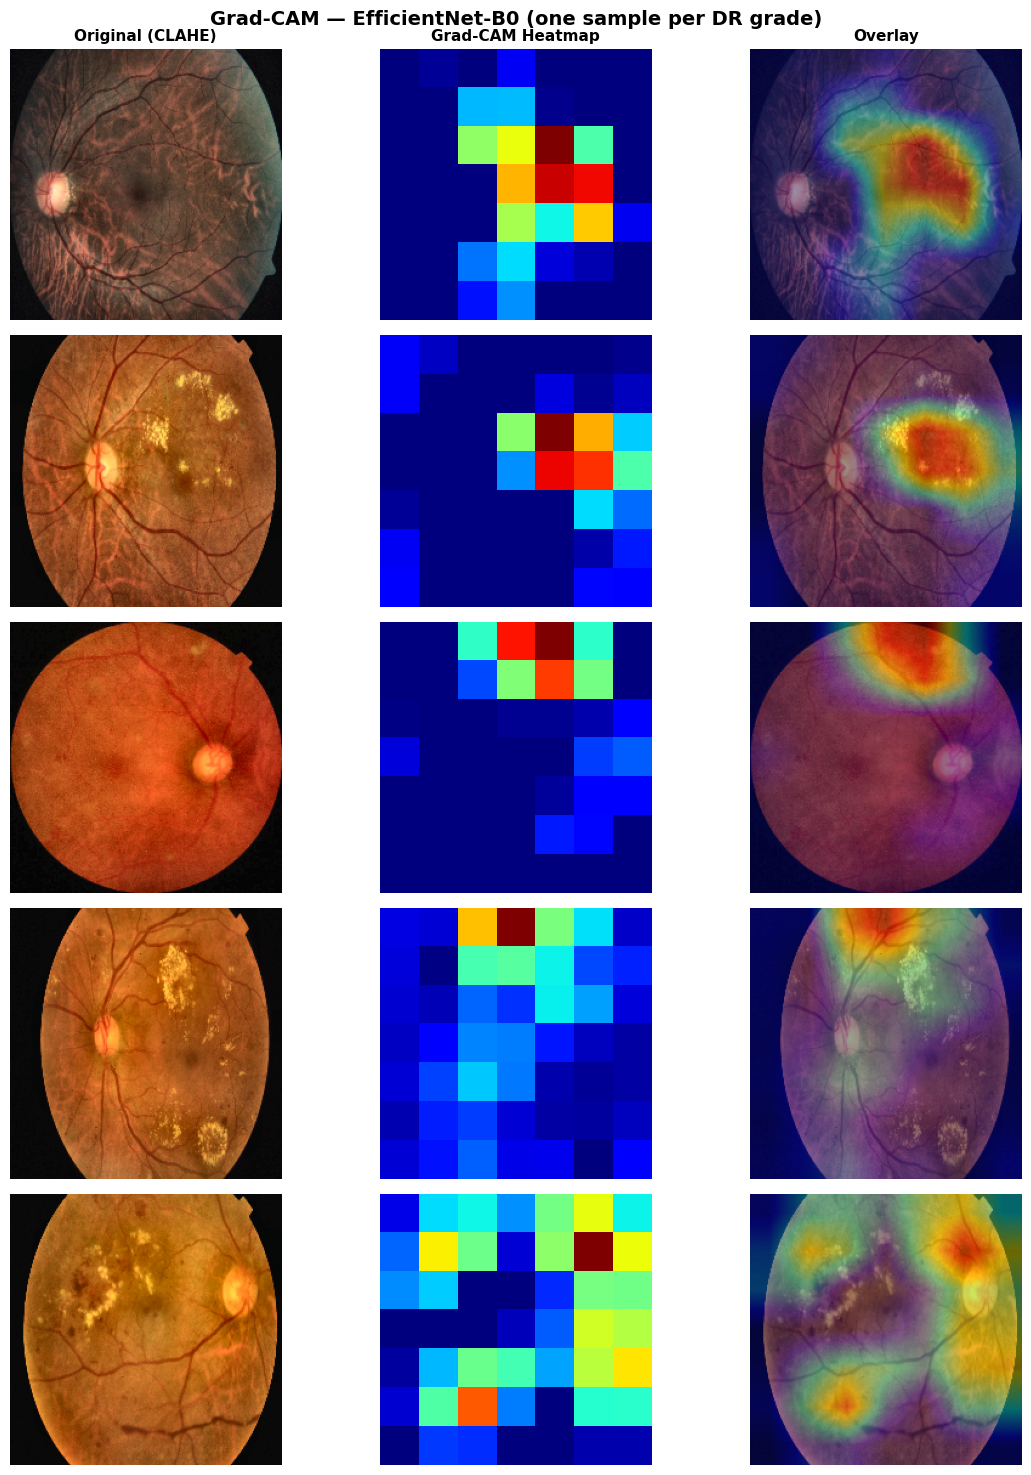

Grad-CAM saved → gradcam_results.png


In [14]:
# ── GRAD-CAM ──────────────────────────────────────────────────────────────────
# Visualizes which retinal regions EfficientNet-B0 focuses on per DR grade.

class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer.register_forward_hook(self._fwd_hook)
        target_layer.register_full_backward_hook(self._bwd_hook)

    def _fwd_hook(self, module, input, output):
        self.activations = output.detach()

    def _bwd_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        features = self.model.features(input_tensor)
        pooled   = self.model.avgpool(features)
        flat     = pooled.flatten(1)
        logits   = self.model.classifier(flat)

        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        logits[0, class_idx].backward()

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam     = (weights * self.activations).sum(dim=1).squeeze()
        cam     = F.relu(cam)
        cam    -= cam.min()
        cam    /= (cam.max() + 1e-8)
        return cam.cpu().numpy(), class_idx


def overlay_cam(orig_np, cam, alpha=0.4):
    cam_resized = cv2.resize(cam, (orig_np.shape[1], orig_np.shape[0]))
    heatmap     = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return (alpha * heatmap + (1 - alpha) * orig_np).astype(np.uint8)


# Target = last conv block of EfficientNet-B0
grad_cam = GradCAM(model, target_layer=model.features[-1])

# One sample per DR grade from test set
sample_rows = []
for grade in range(NUM_CLASSES):
    rows = df_te[df_te['label'] == grade].sample(
        min(1, (df_te['label'] == grade).sum()), random_state=SEED
    )
    sample_rows.append(rows)
sample_df = pd.concat(sample_rows).reset_index(drop=True)

fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(12, NUM_CLASSES * 3))
fig.suptitle('Grad-CAM — EfficientNet-B0 (one sample per DR grade)',
             fontsize=14, fontweight='bold')

col_titles = ['Original (CLAHE)', 'Grad-CAM Heatmap', 'Overlay']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11, fontweight='bold')

for i, (_, row) in enumerate(sample_df.iterrows()):
    orig_pil   = apply_clahe_fast(row['filepath'], IMG_SIZE)
    orig_np    = np.array(orig_pil)
    img_tensor = val_tfm(orig_pil).unsqueeze(0).to(DEVICE)
    img_tensor.requires_grad_(True)

    cam, pred_idx = grad_cam.generate(img_tensor)
    overlay       = overlay_cam(orig_np, cam)

    axes[i, 0].imshow(orig_np)
    axes[i, 0].set_ylabel(f'Grade {row["label"]}\n{CLASS_NAMES[row["label"]]}',
                           fontsize=9, rotation=0, labelpad=60, va='center')
    axes[i, 1].imshow(cam, cmap='jet')
    axes[i, 1].set_xlabel(f'Pred: {CLASS_NAMES[pred_idx]}', fontsize=8)
    axes[i, 2].imshow(overlay)
    for ax in axes[i]:
        ax.axis('off')

plt.tight_layout()
plt.savefig('gradcam_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grad-CAM saved → gradcam_results.png")

In [15]:
import joblib

joblib.dump(best_svm, "svm_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Files saved!")

Files saved!


In [16]:
import os

print(os.listdir("/kaggle/working"))

['__notebook__.ipynb', 'gradcam_results.png', 'svm_model.pkl', 'scaler.pkl']


In [17]:
torch.save(model.state_dict(), "effb0_se_best.pth")

In [18]:
!ls -lh /kaggle/working

total 37M
-rw-r--r-- 1 root root  19M Jun  4 10:00 effb0_se_best.pth
-rw-r--r-- 1 root root 2.3M Jun  4 10:00 gradcam_results.png
---------- 1 root root 2.3M Jun  4 10:00 __notebook__.ipynb
-rw-r--r-- 1 root root  31K Jun  4 10:00 scaler.pkl
-rw-r--r-- 1 root root  14M Jun  4 10:00 svm_model.pkl
